In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r'C:\Users\patel\OneDrive\Documents\Desktop\superstore analysis\train.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Year']  = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (9800, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Shipping Days,Year,Month
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,3,2017,11
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,2017,11
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,4,2017,6
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,7,2016,10
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,7,2016,10


In [4]:
print("=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Data Types ===")
print(df.dtypes)
print("\n=== Summary Stats ===")
df[['Sales','Shipping Days']].describe().round(2)

=== Missing Values ===
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Shipping Days     0
Year              0
Month             0
dtype: int64

=== Data Types ===
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name

,Sales,Shipping Days
count,9800.00,9800.00
mean,230.77,3.96
std,626.65,1.75
min,0.44,0.00
25%,17.25,3.00
50%,54.49,4.00
75%,210.60,5.00
max,22638.48,7.00


In [5]:
print("Total Sales:    $", round(df['Sales'].sum(), 2))
print("Total Orders:  ", df['Order ID'].nunique())
print("Total Customers:", df['Customer ID'].nunique())
print("\n--- Sales by Category ---")
print(df.groupby('Category')['Sales'].sum().sort_values(ascending=False).round(2))
print("\n--- Sales by Region ---")
print(df.groupby('Region')['Sales'].sum().sort_values(ascending=False).round(2))
print("\n--- Top 10 Customers ---")
print(df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10).round(2))

Total Sales:    $ 2261536.78
Total Orders:   4922
Total Customers: 793

--- Sales by Category ---
Category
Technology         827455.87
Furniture          728658.58
Office Supplies    705422.33
Name: Sales, dtype: float64

--- Sales by Region ---
Region
West       710219.68
East       669518.73
Central    492646.91
South      389151.46
Name: Sales, dtype: float64

--- Top 10 Customers ---
Customer Name
Sean Miller           25043.05
Tamara Chand          19052.22
Raymond Buch          15117.34
Tom Ashbrook          14595.62
Adrian Barton         14473.57
Ken Lonsdale          14175.23
Sanjit Chand          14142.33
Hunter Lopez          12873.30
Sanjit Engle          12209.44
Christopher Conant    12129.07
Name: Sales, dtype: float64


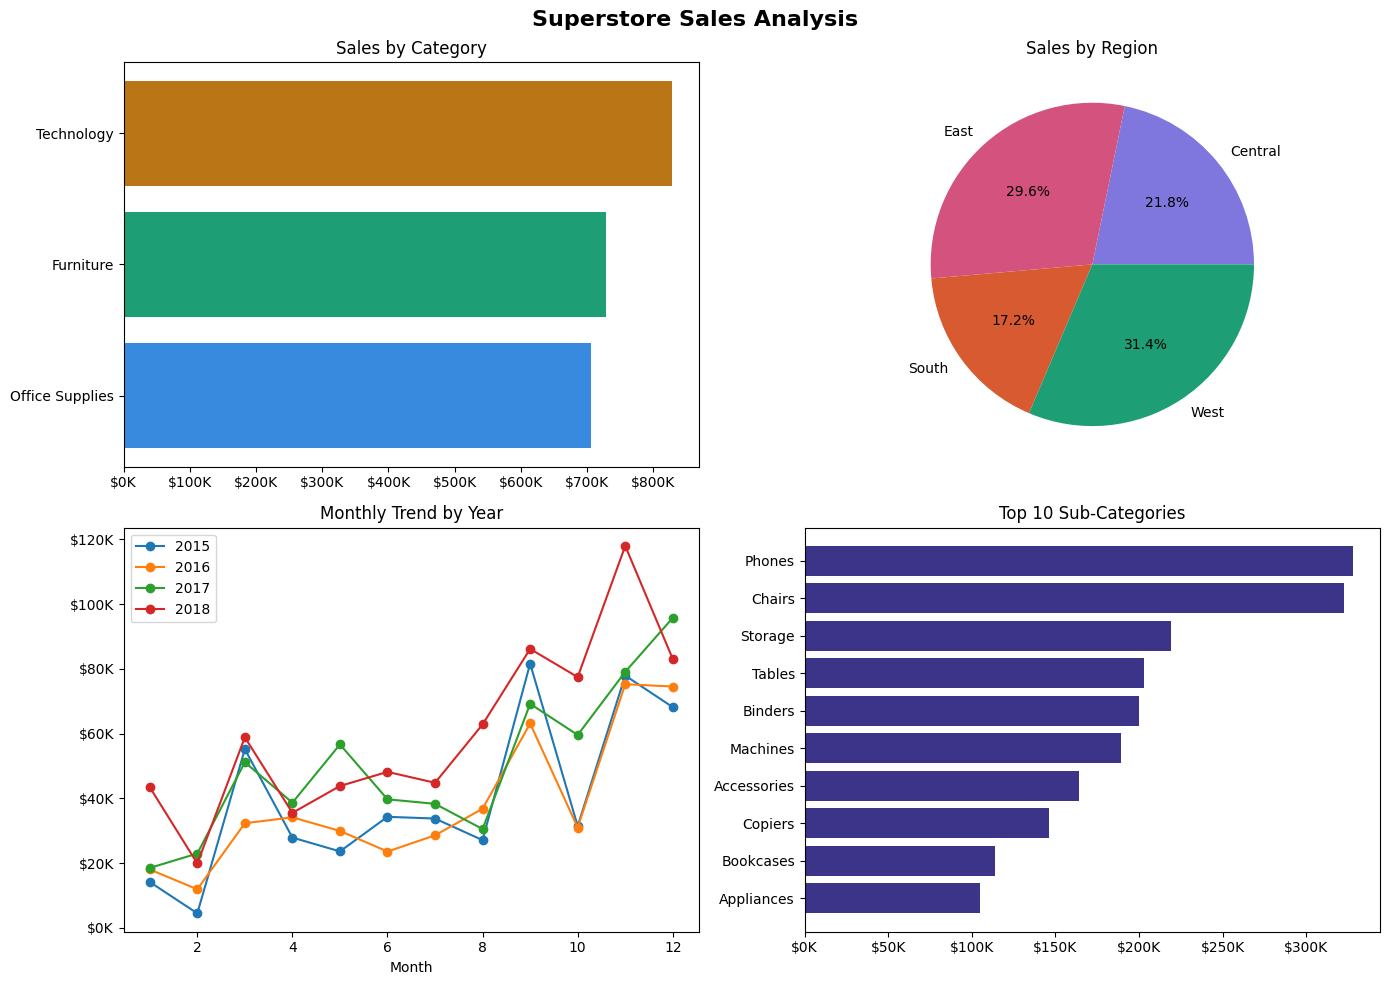

Saved as superstore_eda.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Superstore Sales Analysis', fontsize=16, fontweight='bold')

cat_sales = df.groupby('Category')['Sales'].sum().sort_values()
axes[0,0].barh(cat_sales.index, cat_sales.values, color=['#378ADD','#1D9E75','#BA7517'])
axes[0,0].set_title('Sales by Category')
axes[0,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

region_sales = df.groupby('Region')['Sales'].sum()
axes[0,1].pie(region_sales, labels=region_sales.index, autopct='%1.1f%%',
              colors=['#7F77DD','#D4537E','#D85A30','#1D9E75'])
axes[0,1].set_title('Sales by Region')

monthly = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
for yr in sorted(monthly['Year'].unique()):
    d = monthly[monthly['Year']==yr]
    axes[1,0].plot(d['Month'], d['Sales'], marker='o', label=str(yr))
axes[1,0].set_title('Monthly Trend by Year')
axes[1,0].set_xlabel('Month')
axes[1,0].legend()
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

sub = df.groupby('Sub-Category')['Sales'].sum().sort_values().tail(10)
axes[1,1].barh(sub.index, sub.values, color='#3C3489')
axes[1,1].set_title('Top 10 Sub-Categories')
axes[1,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('superstore_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as superstore_eda.png")


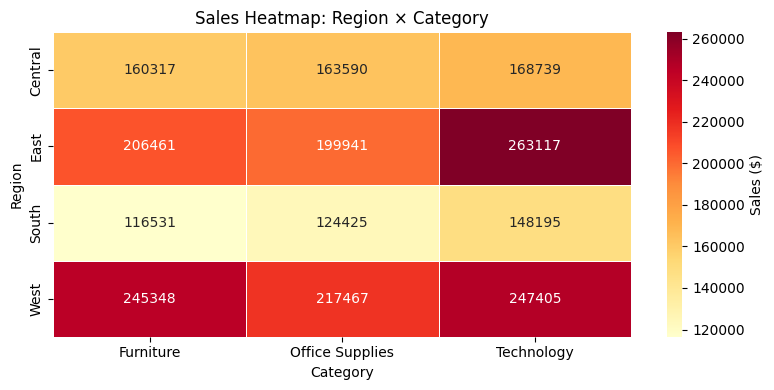

In [8]:
pivot = df.pivot_table(values='Sales', index='Region',
                       columns='Category', aggfunc='sum')
plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Sales ($)'})
plt.title('Sales Heatmap: Region × Category')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150)
plt.show()